# Knowledge Factor Investigation 

These are experimental codes:      
- Briefing the data
- Tuning optimal hyperparameter
- Visualize the performance of Models
- Visualize the importance
- Visualize and summerize impacts

In [1]:
%pwd

'/mnt/d/OneDrive/MLD01_Article/MLD01e_Code'

In [2]:
%cd ..

/mnt/d/OneDrive/MLD01_Article


/home/linux/anaconda3/envs/tf/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Import PAckage

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from xgboost import XGBClassifier 

## Append Data

In [4]:
df_2016 = pd.read_parquet('Data/01_Napel2016.parquet')
df_2016['Year'] = 2016
df_2022 = pd.read_parquet('Data/01_Napel2022.parquet')
df_2022['Year'] = 2022

In [5]:
df_all = pd.concat([df_2016, df_2022], axis = 0)

In [6]:
df_all.shape

(11568, 352)

In [7]:
df_all = df_all.dropna(axis=1, how="any")

In [8]:
df_all.shape

(11568, 277)

In [9]:
df_all = df_all.set_index(['PSU', 'HHLD'])

In [10]:
df_all.columns

Index(['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age',
       'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor',
       'Edu_Master',
       ...
       'SoilWaterConservationPast25', 'VisitClimateOfficePast25',
       'FoodConsumptionHabitPast25', 'OfffarmActiPast25',
       'NonFarmEmployPast25', 'FamilyMigrationPast25', 'RiskReductionPast25',
       'RoadImprovementPast25', 'CommunityPartipationPast25', 'Year'],
      dtype='object', length=275)

In [11]:
df_all["EcoBelt"] = df_all["EcoBelt"].str.replace('Tarai', 'Terai')

In [12]:
eco_dummies = pd.get_dummies(df_all["EcoBelt"], prefix="EcoBelt").astype(int)
df_all = pd.concat([df_all, eco_dummies], axis=1)

In [13]:
prov_dummies = pd.get_dummies(df_all["Prov"], prefix="Prov").astype(int)
df_all = pd.concat([df_all, prov_dummies], axis=1)

In [14]:
df_all

EcoBelt          Prov  Rural_Dummy  Respon_Female  Respon_Age  \
PSU   HHLD                                                                   
101.0 1.0   Mountain         Koshi            1            1.0        49.0   
      2.0   Mountain         Koshi            1            0.0        55.0   
      3.0   Mountain         Koshi            1            1.0        46.0   
      4.0   Mountain         Koshi            1            0.0        78.0   
      5.0   Mountain         Koshi            1            0.0        70.0   
...              ...           ...          ...            ...         ...   
826.0 16.0     Terai  Sudurpaschim            0            0.0        47.0   
      17.0     Terai  Sudurpaschim            0            0.0        60.0   
      18.0     Terai  Sudurpaschim            0            1.0        47.0   
      19.0     Terai  Sudurpaschim            0            0.0        55.0   
      20.0     Terai  Sudurpaschim            0            0.0        45.0   

            LivingYear  Edu_UnderSLC  Edu_Certificate  Edu_Bachelor  \
PSU   HHLD                                                            
101.0 1.0         49.0             0                0             0   
      2.0         55.0             1                0             0   
      3.0         25.0             0                0             0   
      4.0         78.0             0                0             0   
      5.0         70.0             1                0             0   
...                ...           ...              ...           ...   
826.0 16.0        40.0             1                0             0   
      17.0        35.0             0                0             0   
      18.0        32.0             1                0             0   
      19.0        55.0             0                0             0   
      20.0        25.0             1                0             0   

            Edu_Master  ...  EcoBelt_Hill  EcoBelt_Mountain  EcoBelt_Terai  \
PSU   HHLD              ...                                                  
101.0 1.0            0  ...             0                 1              0   
      2.0            0  ...             0                 1              0   
      3.0            0  ...             0                 1              0   
      4.0            0  ...             0                 1              0   
      5.0            0  ...             0                 1              0   
...                ...  ...           ...               ...            ...   
826.0 16.0           0  ...             0                 0              1   
      17.0           0  ...             0                 0              1   
      18.0           0  ...             0                 0              1   
      19.0           0  ...             0                 0              1   
      20.0           0  ...             0                 0              1   

            Prov_Bagmati  Prov_Gandaki  Prov_Karnali  Prov_Koshi  \
PSU   HHLD                                                         
101.0 1.0              0             0             0           1   
      2.0              0             0             0           1   
      3.0              0             0             0           1   
      4.0              0             0             0           1   
      5.0              0             0             0           1   
...                  ...           ...           ...         ...   
826.0 16.0             0             0             0           0   
      17.0             0             0             0           0   
      18.0             0             0             0           0   
      19.0             0             0             0           0   
      20.0             0             0             0           0   

            Prov_Lumbini  Prov_Madhesh  Prov_Sudurpaschim  
PSU   HHLD                                                 
101.0 1.0              0             0                

### Revise Income Resources

In [15]:
df_all['IncomeResAgri_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 1).any(axis=1).astype(int)
df_all['IncomeResWage_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 2).any(axis=1).astype(int)
df_all['IncomeResNonAgriBusi_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 3).any(axis=1).astype(int)
df_all['IncomeResRemit_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 4).any(axis=1).astype(int)
df_all['IncomeResOthers_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 5).any(axis=1).astype(int)

In [16]:
df_all['ResidenceOwn_dummy'] = (df_all['Own_Resid'] == 1).astype(int)
df_all['ResidenceRent_dummy'] = (df_all['Own_Resid'] == 2).astype(int)
df_all['ResidenceInstitu_dummy'] = (df_all['Own_Resid'] == 3).astype(int)
df_all['ResidenceOthers_dummy'] = (df_all['Own_Resid'] == 4).astype(int)

In [17]:
df_all['ResidInfraPerman_dummy'] = (df_all['Resid_Type'] == 1).astype(int)
df_all['ResidInfraSemi_dummy'] = (df_all['Resid_Type'] == 2).astype(int)
df_all['ResidInfraKachchi_dummy'] = (df_all['Resid_Type'] == 3).astype(int)
df_all['ResidInfraOthers_dummy'] = (df_all['Resid_Type'] == 4).astype(int)

## Checking "HeardClimate_Dummy"

### Dataset building

In [18]:
for here in range(0, df_all.shape[1], 40):
    print(df_all.columns[0+here:40+here])

Index(['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age',
       'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor',
       'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year',
       'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio',
       'Literal_Ratio', 'Household_memberNum', 'Own_Resid', 'Resid_Type',
       'WaterS1', 'WaterS2', 'WaterS3', 'CookFuelS1', 'CookFuelS2',
       'CookFuelS3', 'LightEnergy', 'Toilet', 'IncomeS1', 'IncomeS2',
       'IncomeS3', 'Remittance_dummy', 'Have_AgriLand', 'Radio_dummy',
       'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy'],
      dtype='object')
Index(['Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy',
       'OtherVehi_dummy', 'Refrige_dummy', 'HouseHead_AgriExpYear',
       'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport',
       'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market',
       'Dist_AgriSupport', 'FramMechan', 'CropIncome', 'L

In [59]:
df_inuse = df_all[['HeardClimate_Dummy', 
                   'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 
                   'Edu_Bachelor', 'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year'
                   
                  ]]

In [60]:
variname_readable = {'HeardClimate_Dummy':'Heard about Climate Change Dummy', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year"                    
                    }

In [61]:
data_summary = df_inuse.describe().T

In [62]:
data_summary.index = data_summary.index.map(variname_readable)

In [63]:
data_summary.to_excel("MLD01e_Results/Table01_DataSummary_v1.xlsx")

In [64]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

## Hyper Tunining

In [25]:
y = df_inuse['Heard about Climate Change Dummy'].astype(int)
X = df_inuse.drop(columns=['Heard about Climate Change Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [26]:
clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    device = 'cuda'
)

In [27]:
param_distributions = {
    'n_estimators': [200, 500, 1_000, 2_000],
    'max_depth': [4,  8, 16],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 5, 10]
}

In [28]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=200,                 # increase for a more exhaustive search if you have time
    scoring='accuracy',
    return_train_score=True,
    cv=cv,
    verbose=3,
    refit=True,                # refit on entire data with best params
    random_state=42
)

search.fit(X, y)

Fitting 10 folds for each of 200 candidates, totalling 2000 fits


/home/linux/anaconda3/envs/tf/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [14:37:34] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


[CV 1/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.714) total time=   5.9s
[CV 2/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.735) total time=   4.1s
[CV 3/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.753) total time=   4.1s
[CV 4/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.749) total time=   4.0s
[CV 5/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.755) total time=   4.0s
[CV 6/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=42, ...),
                   n_iter=200,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 8, 16],
                                        'min_child_weight': [1, 2, 5, 10],
                                        'n_estimators': [200, 500, 1000, 2000],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, return_train_score=True, scoring='accuracy',
                   verbose=3)

In [29]:
# 7) Results
print("Best mean CV accuracy:", f"{search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Best mean CV accuracy: 0.7611
Best params:
  subsample: 1.0
  n_estimators: 200
  min_child_weight: 10
  max_depth: 8
  learning_rate: 0.05
  colsample_bytree: 0.7


In [30]:
cvres = pd.DataFrame(search.cv_results_)

In [31]:
cvres.to_parquet('MLD01e_Results/MLD01e_C01_KnowledgeFactorInvestigation.parquet')

In [32]:
cols = ['mean_test_score', 'std_test_score', 'rank_test_score'] + [c for c in cvres.columns if c.startswith('param_')]
cvres_sorted = cvres.sort_values('rank_test_score')[cols].head(10)

In [33]:
cvres_sorted

,mean_test_score,std_test_score,rank_test_score,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_colsample_bytree
84,0.761064,0.010942,1,1.0,200,10,8,0.05,0.7
189,0.760717,0.010005,2,0.9,1000,2,8,0.01,1.0
34,0.758816,0.008788,3,1.0,500,10,8,0.01,0.9
82,0.758730,0.011842,4,0.7,1000,1,16,0.01,0.9
62,0.758643,0.010226,5,0.7,1000,2,16,0.01,0.9
153,0.758384,0.009674,6,0.7,200,10,16,0.05,0.7
29,0.758297,0.009210,7,0.9,500,5,8,0.01,1.0
59,0.758038,0.008950,8,0.9,500,5,8,0.01,0.8
114,0.757952,0.009809,9,0.9,200,5,8,0.05,0.7
111,0.757866,0.008838,10,0.7,500,5,16,0.01,1.0


## 10-fold 10-epoch Estimation

In [65]:
y = df_inuse['Heard about Climate Change Dummy'].astype(int)
X = df_inuse.drop(columns=['Heard about Climate Change Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [66]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [68]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [67]:
prob_matrix = np.zeros([X.shape[0], 10])

In [69]:
acc_lines = []
importances_df = []
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for random_seed in range(42, 42*11, 42):
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)


        metrics = Metrics(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred).flatten()
        line  = [fold, random_seed] + metrics + list(cm)
        importances = clf.feature_importances_

        acc_lines.append(line)
        importances_df.append(importances)
        
    

fold: 1, random_seed:42
Accuracy: 0.7450302506482281
Precision: 0.6927710843373494
Recall   : 0.7084188911704312
F1-score : 0.700507614213198
fold: 1, random_seed:84
Accuracy: 0.7467588591184097
Precision: 0.6924603174603174
Recall   : 0.7166324435318275
F1-score : 0.7043390514631686
fold: 1, random_seed:126
Accuracy: 0.7329299913569577
Precision: 0.6731517509727627
Recall   : 0.7104722792607803
F1-score : 0.6913086913086913
fold: 1, random_seed:168
Accuracy: 0.7433016421780466
Precision: 0.693089430894309
Recall   : 0.7002053388090349
F1-score : 0.6966292134831461
fold: 1, random_seed:210
Accuracy: 0.749351771823682
Precision: 0.695049504950495
Recall   : 0.7207392197125256
F1-score : 0.7076612903225806
fold: 1, random_seed:252
Accuracy: 0.7484874675885912
Precision: 0.696
Recall   : 0.7145790554414785
F1-score : 0.7051671732522796
fold: 1, random_seed:294
Accuracy: 0.7450302506482281
Precision: 0.694331983805668
Recall   : 0.704312114989733
F1-score : 0.6992864424057085
fold: 1, rand

In [70]:
acc_df = pd.DataFrame(acc_lines)

In [71]:
acc_df.columns = ['fold', 'random_seed', 'acc', 'prec', 'recall', 'f1', 'TN', 'FP', 'FN', 'TP']

In [72]:
acc_df.to_excel('MLD01e_Results/Table02_AccuracyTable_v1.xlsx')

In [80]:
acc_df[['acc', 'prec', 'recall', 'f1']].mean(axis=0)

acc       0.757010
prec      0.710271
recall    0.716019
f1        0.713012
dtype: float64

In [73]:
import_df = pd.DataFrame(importances_df).T

In [74]:
import_df.index = X.columns

In [75]:
import_df['Mean_Importance'] = import_df.iloc[:,:100].mean(axis = 1)
import_df['Std_Importance'] = import_df.iloc[:,:100].std(axis = 1)

In [76]:
import_df['Mean_Importance'] 

Female Dummy                                   0.010984
Age                                            0.008390
Years Living in Community                      0.008673
Education under Secondary Certificate Dummy    0.019856
Education with Secondary Certificate Dummy     0.016888
                                                 ...   
Livestock Income                               0.009002
Non-agricultural Income                        0.011307
Business Income                                0.008692
Total Income                                   0.010105
Survey Year                                    0.025294
Name: Mean_Importance, Length: 69, dtype: float32

In [77]:
# Get importance values
importances = pd.Series(import_df['Mean_Importance'] , index=import_df.index)

# Sort descending
importances = importances.sort_values(ascending=False)

print(importances.head(20))   # Top 20 important features

Education Year                                  0.090611
Illiterate Dummy                                0.082533
Having Computer Dummy                           0.072497
Having Telephone Dummy                          0.034323
Survey Year                                     0.025294
Having Mobile Dummy                             0.022610
Literate Education Dummy                        0.021085
Member with 12-Year Education or above Ratio    0.020991
Education under Secondary Certificate Dummy     0.019856
Province Koshi Dummy                            0.018335
Having Refrigator Dummy                         0.017809
Province Karnali Dummy                          0.017411
EcoBelt Terai Dummy                             0.017313
Having TV Dummy                                 0.017255
Education with Secondary Certificate Dummy      0.016888
Farm Mechanization Dummy                        0.015980
Having Car Dummy                                0.015447
Province Madhesh Dummy         

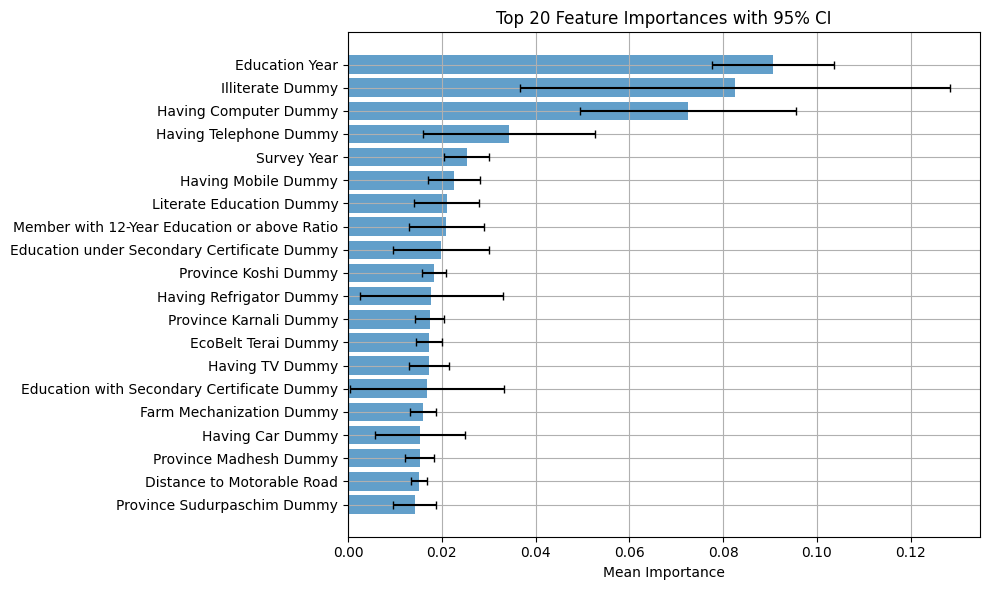

In [78]:
top20 = import_df.sort_values("Mean_Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(
    top20.index, 
    top20["Mean_Importance"], 
    xerr=top20["Std_Importance"] * 1.96, 
    align="center", 
    alpha=0.7, 
    ecolor="black", 
    capsize=3
)
plt.xlabel("Mean Importance")
plt.title("Top 20 Feature Importances with 95% CI")
plt.grid()
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()
plt.show()

In [81]:
importances.head(20).index

Index(['Education Year', 'Illiterate Dummy', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Literate Education Dummy',
       'Member with 12-Year Education or above Ratio',
       'Education under Secondary Certificate Dummy', 'Province Koshi Dummy',
       'Having Refrigator Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having TV Dummy',
       'Education with Secondary Certificate Dummy',
       'Farm Mechanization Dummy', 'Having Car Dummy',
       'Province Madhesh Dummy', 'Distance to Motorable Road',
       'Province Sudurpaschim Dummy'],
      dtype='object')

## Compute Impact

### Illiterate Dummy

In [131]:
name = 'Illiterate Dummy'

In [132]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [133]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [134]:
prob_matrix.mean().mean()

-0.07155747852844663

In [135]:
prob_matrix.mean().std()

0.006463653167593619

In [136]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

-0.05888871831996313

In [137]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

-0.08422623873693012

In [138]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

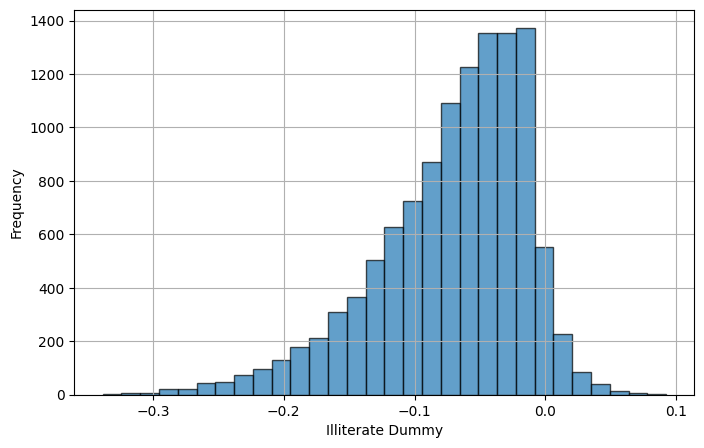

In [139]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Having Computer Dummy

In [140]:
name = 'Having Computer Dummy'

In [141]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [142]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [143]:
prob_matrix.mean().mean()

0.06816663130520689

In [144]:
prob_matrix.mean().std()

0.0032090015484761945

In [145]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

0.07445627434022023

In [146]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

0.06187698827019355

In [147]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

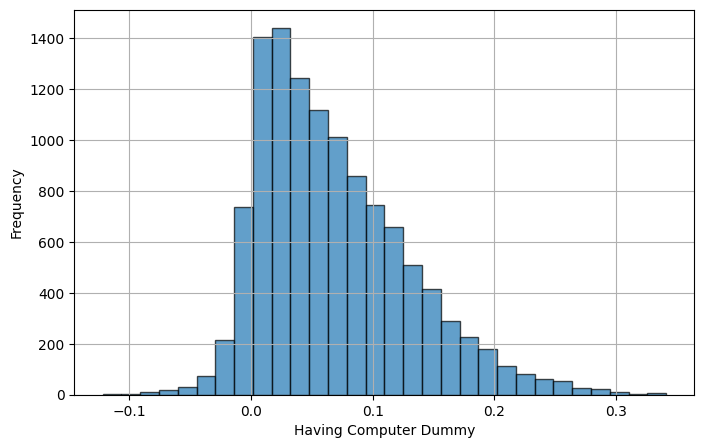

In [148]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Having Telephone Dummy

In [149]:
name = 'Having Telephone Dummy'

In [150]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [151]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [152]:
prob_matrix.mean().mean()

0.0366448175406058

In [153]:
prob_matrix.mean().std()

0.002043604750622

In [154]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

0.04065028285182492

In [155]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

0.03263935222938668

In [156]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

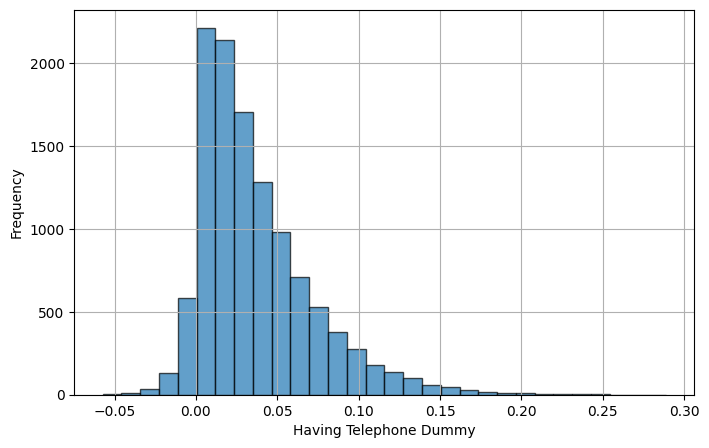

In [157]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Survey Year

In [158]:
name = 'Survey Year'

In [159]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [160]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 2022
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 2016
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [161]:
prob_matrix.mean().mean()

-0.12832768426279478

In [162]:
prob_matrix.mean().std()

0.004819157434655791

In [163]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

-0.11888213569086943

In [164]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

-0.13777323283472012

In [165]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

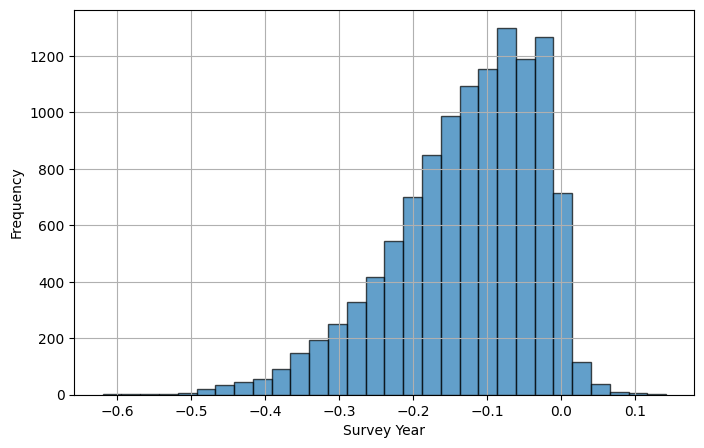

In [166]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Having Mobile Dummy

In [167]:
importances.head(20).index

Index(['Education Year', 'Illiterate Dummy', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Literate Education Dummy',
       'Member with 12-Year Education or above Ratio',
       'Education under Secondary Certificate Dummy', 'Province Koshi Dummy',
       'Having Refrigator Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having TV Dummy',
       'Education with Secondary Certificate Dummy',
       'Farm Mechanization Dummy', 'Having Car Dummy',
       'Province Madhesh Dummy', 'Distance to Motorable Road',
       'Province Sudurpaschim Dummy'],
      dtype='object')

In [168]:
name = 'Having Mobile Dummy'

In [169]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [170]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [171]:
prob_matrix.mean().mean()

-0.03143112261387208

In [172]:
prob_matrix.mean().std()

0.003424553720020192

In [173]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

-0.0247189973226325

In [174]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

-0.03814324790511165

In [175]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

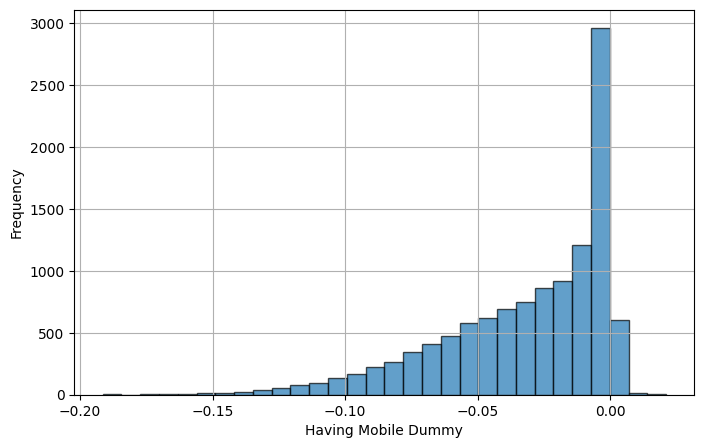

In [176]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Literate Education Dummy

In [177]:
importances.head(20).index

Index(['Education Year', 'Illiterate Dummy', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Literate Education Dummy',
       'Member with 12-Year Education or above Ratio',
       'Education under Secondary Certificate Dummy', 'Province Koshi Dummy',
       'Having Refrigator Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having TV Dummy',
       'Education with Secondary Certificate Dummy',
       'Farm Mechanization Dummy', 'Having Car Dummy',
       'Province Madhesh Dummy', 'Distance to Motorable Road',
       'Province Sudurpaschim Dummy'],
      dtype='object')

In [178]:
name = 'Literate Education Dummy'

In [179]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [180]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [181]:
prob_matrix.mean().mean()

-0.005178674642128817

In [182]:
prob_matrix.mean().std()

0.0031084617661973324

In [183]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

0.0009139104196179536

In [184]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

-0.011271259703875589

In [185]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

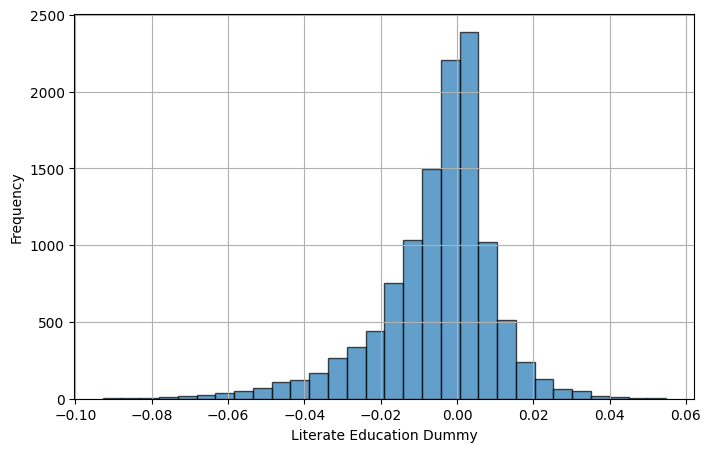

In [186]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Education under Secondary Certificate Dummy

In [187]:
importances.head(20).index

Index(['Education Year', 'Illiterate Dummy', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Literate Education Dummy',
       'Member with 12-Year Education or above Ratio',
       'Education under Secondary Certificate Dummy', 'Province Koshi Dummy',
       'Having Refrigator Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having TV Dummy',
       'Education with Secondary Certificate Dummy',
       'Farm Mechanization Dummy', 'Having Car Dummy',
       'Province Madhesh Dummy', 'Distance to Motorable Road',
       'Province Sudurpaschim Dummy'],
      dtype='object')

In [188]:
name = 'Education under Secondary Certificate Dummy'

In [189]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [190]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [191]:
prob_matrix.mean().mean()

0.0028489785370786314

In [192]:
prob_matrix.mean().std()

0.004762556966294509

In [193]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

0.01218359019101587

In [194]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

-0.0064856331168586055

In [195]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

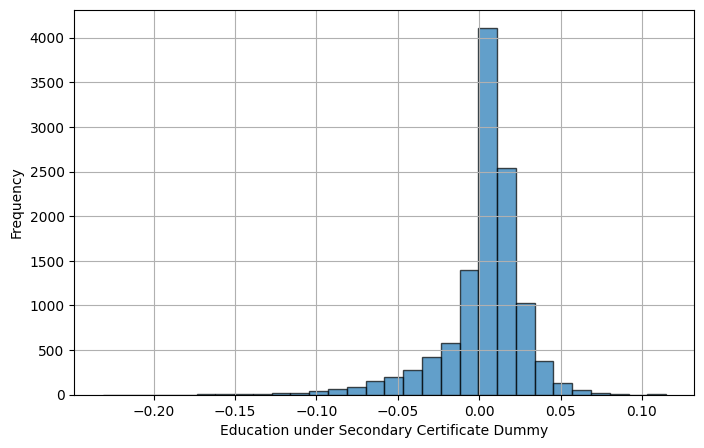

In [196]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Province Koshi Dummy

In [197]:
importances.head(20).index

Index(['Education Year', 'Illiterate Dummy', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Literate Education Dummy',
       'Member with 12-Year Education or above Ratio',
       'Education under Secondary Certificate Dummy', 'Province Koshi Dummy',
       'Having Refrigator Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having TV Dummy',
       'Education with Secondary Certificate Dummy',
       'Farm Mechanization Dummy', 'Having Car Dummy',
       'Province Madhesh Dummy', 'Distance to Motorable Road',
       'Province Sudurpaschim Dummy'],
      dtype='object')

In [198]:
name = 'Province Koshi Dummy'

In [199]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [200]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [201]:
prob_matrix.mean().mean()

0.08149288915606366

In [202]:
prob_matrix.mean().std()

0.0017495141148100395

In [203]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

0.08492193682109134

In [204]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

0.07806384149103598

In [205]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

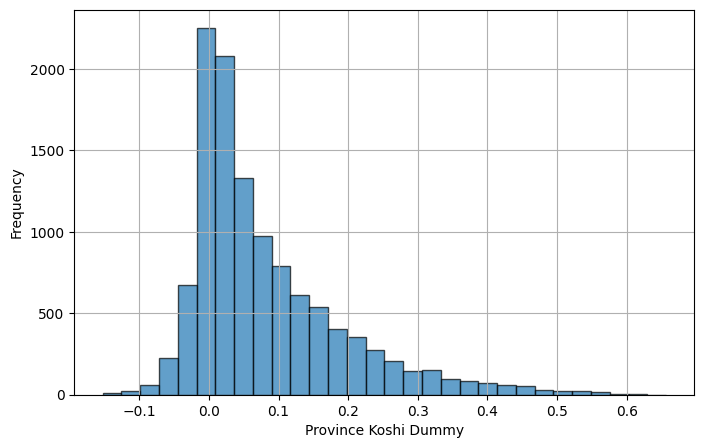

In [206]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Having Refrigator Dummy

In [207]:
importances.head(20).index

Index(['Education Year', 'Illiterate Dummy', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Literate Education Dummy',
       'Member with 12-Year Education or above Ratio',
       'Education under Secondary Certificate Dummy', 'Province Koshi Dummy',
       'Having Refrigator Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having TV Dummy',
       'Education with Secondary Certificate Dummy',
       'Farm Mechanization Dummy', 'Having Car Dummy',
       'Province Madhesh Dummy', 'Distance to Motorable Road',
       'Province Sudurpaschim Dummy'],
      dtype='object')

In [208]:
name = 'Having Refrigator Dummy'

In [209]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [210]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [211]:
prob_matrix.mean().mean()

0.00890617282290036

In [212]:
prob_matrix.mean().std()

0.0012098823195806762

In [213]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

0.011277542169278485

In [214]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

0.006534803476522234

In [215]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

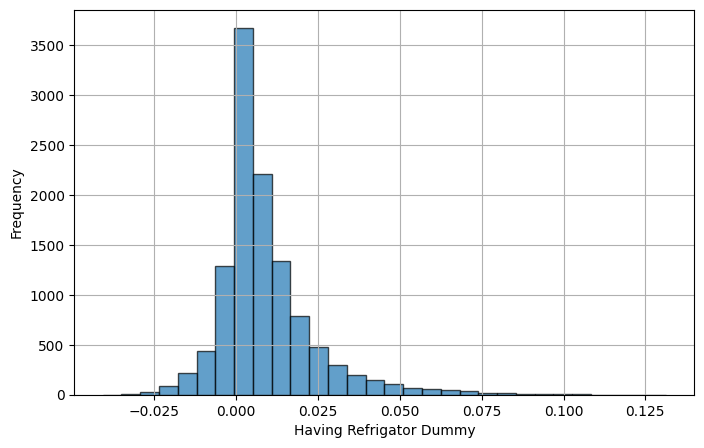

In [216]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Province Karnali Dummy

In [217]:
importances.head(20).index

Index(['Education Year', 'Illiterate Dummy', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Literate Education Dummy',
       'Member with 12-Year Education or above Ratio',
       'Education under Secondary Certificate Dummy', 'Province Koshi Dummy',
       'Having Refrigator Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having TV Dummy',
       'Education with Secondary Certificate Dummy',
       'Farm Mechanization Dummy', 'Having Car Dummy',
       'Province Madhesh Dummy', 'Distance to Motorable Road',
       'Province Sudurpaschim Dummy'],
      dtype='object')

In [218]:
name = 'Province Karnali Dummy'

In [219]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [220]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [221]:
prob_matrix.mean().mean()

-0.062024630488281815

In [222]:
prob_matrix.mean().std()

0.0019544091624572523

In [223]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

-0.0581939885298656

In [224]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

-0.06585527244669803

In [225]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

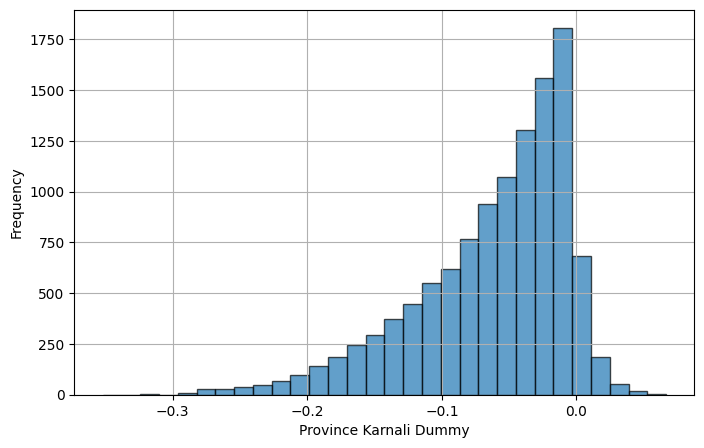

In [226]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### EcoBelt Terai Dummy

In [227]:
importances.head(20).index

Index(['Education Year', 'Illiterate Dummy', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Literate Education Dummy',
       'Member with 12-Year Education or above Ratio',
       'Education under Secondary Certificate Dummy', 'Province Koshi Dummy',
       'Having Refrigator Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having TV Dummy',
       'Education with Secondary Certificate Dummy',
       'Farm Mechanization Dummy', 'Having Car Dummy',
       'Province Madhesh Dummy', 'Distance to Motorable Road',
       'Province Sudurpaschim Dummy'],
      dtype='object')

In [228]:
name = 'EcoBelt Terai Dummy'

In [229]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [230]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [231]:
prob_matrix.mean().mean()

0.036538295504778114

In [232]:
prob_matrix.mean().std()

0.0010578163877741908

In [233]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

0.03861161562481553

In [234]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

0.0344649753847407

In [235]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

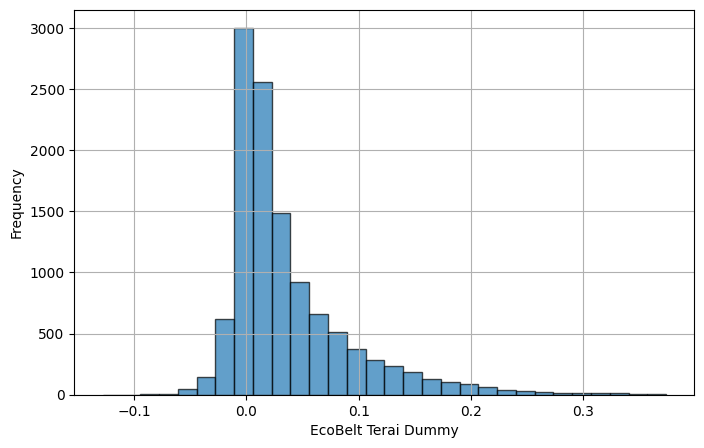

In [236]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Having TV Dummy

In [237]:
importances.head(20).index

Index(['Education Year', 'Illiterate Dummy', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Literate Education Dummy',
       'Member with 12-Year Education or above Ratio',
       'Education under Secondary Certificate Dummy', 'Province Koshi Dummy',
       'Having Refrigator Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having TV Dummy',
       'Education with Secondary Certificate Dummy',
       'Farm Mechanization Dummy', 'Having Car Dummy',
       'Province Madhesh Dummy', 'Distance to Motorable Road',
       'Province Sudurpaschim Dummy'],
      dtype='object')

In [238]:
name = 'Having TV Dummy'

In [239]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [240]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [241]:
prob_matrix.mean().mean()

0.021387822889376858

In [242]:
prob_matrix.mean().std()

0.0004128113145516022

In [243]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

0.022196933065897997

In [244]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

0.020578712712855718

In [245]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

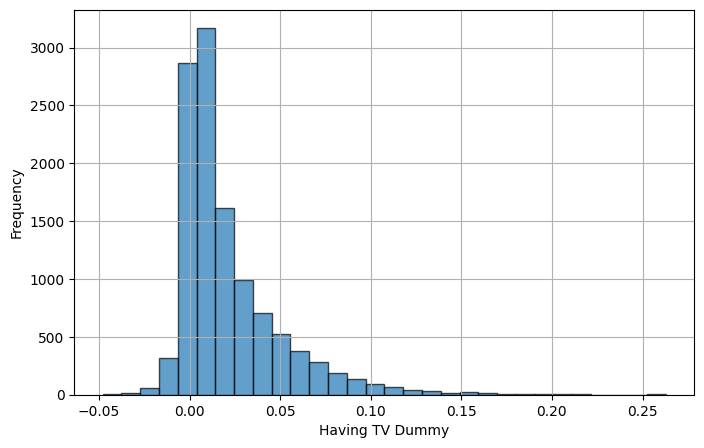

In [246]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Education with Secondary Certificate Dummy

In [247]:
importances.head(20).index

Index(['Education Year', 'Illiterate Dummy', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Literate Education Dummy',
       'Member with 12-Year Education or above Ratio',
       'Education under Secondary Certificate Dummy', 'Province Koshi Dummy',
       'Having Refrigator Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having TV Dummy',
       'Education with Secondary Certificate Dummy',
       'Farm Mechanization Dummy', 'Having Car Dummy',
       'Province Madhesh Dummy', 'Distance to Motorable Road',
       'Province Sudurpaschim Dummy'],
      dtype='object')

In [248]:
name = 'Education with Secondary Certificate Dummy'

In [249]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [250]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [251]:
prob_matrix.mean().mean()

0.002929966914484259

In [252]:
prob_matrix.mean().std()

0.0013053009019845135

In [253]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

0.0054883566823739054

In [254]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

0.00037157714659461286

In [255]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

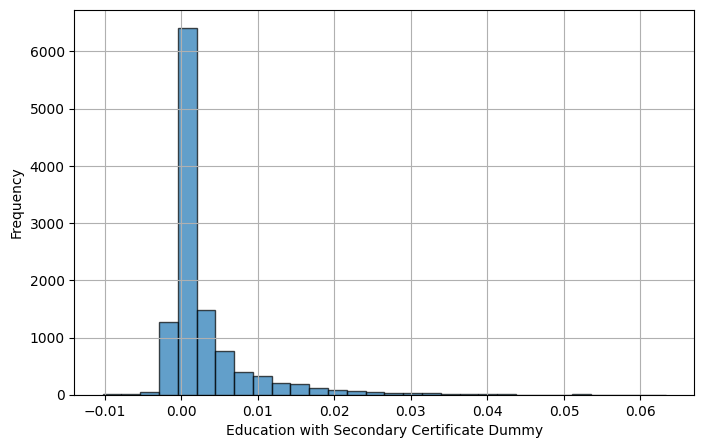

In [256]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Farm Mechanization Dummy

In [257]:
importances.head(20).index

Index(['Education Year', 'Illiterate Dummy', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Literate Education Dummy',
       'Member with 12-Year Education or above Ratio',
       'Education under Secondary Certificate Dummy', 'Province Koshi Dummy',
       'Having Refrigator Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having TV Dummy',
       'Education with Secondary Certificate Dummy',
       'Farm Mechanization Dummy', 'Having Car Dummy',
       'Province Madhesh Dummy', 'Distance to Motorable Road',
       'Province Sudurpaschim Dummy'],
      dtype='object')

In [258]:
name = 'Farm Mechanization Dummy'

In [259]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [260]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [261]:
prob_matrix.mean().mean()

0.0015200587463958697

In [262]:
prob_matrix.mean().std()

0.000978573842452091

In [263]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

0.0034380634776019683

In [264]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

-0.00039794598481022883

In [265]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

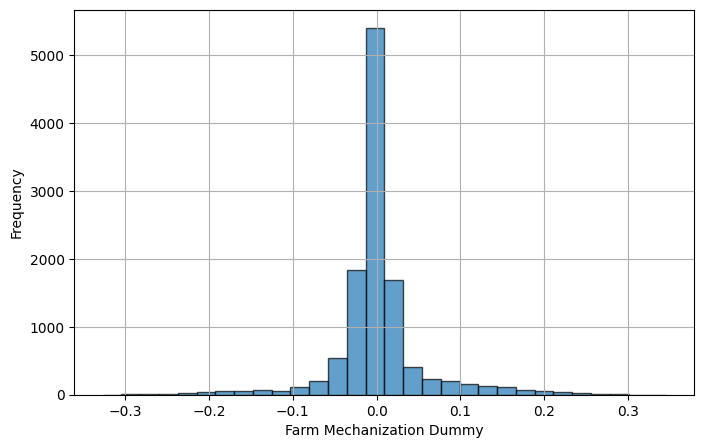

In [266]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Having Car Dummy

In [267]:
importances.head(20).index

Index(['Education Year', 'Illiterate Dummy', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Literate Education Dummy',
       'Member with 12-Year Education or above Ratio',
       'Education under Secondary Certificate Dummy', 'Province Koshi Dummy',
       'Having Refrigator Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having TV Dummy',
       'Education with Secondary Certificate Dummy',
       'Farm Mechanization Dummy', 'Having Car Dummy',
       'Province Madhesh Dummy', 'Distance to Motorable Road',
       'Province Sudurpaschim Dummy'],
      dtype='object')

In [268]:
name = 'Having Car Dummy'

In [269]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [270]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [271]:
prob_matrix.mean().mean()

-0.0054033879380844495

In [272]:
prob_matrix.mean().std()

0.0010244349006842297

In [273]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

-0.003395495532743359

In [274]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

-0.00741128034342554

In [275]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

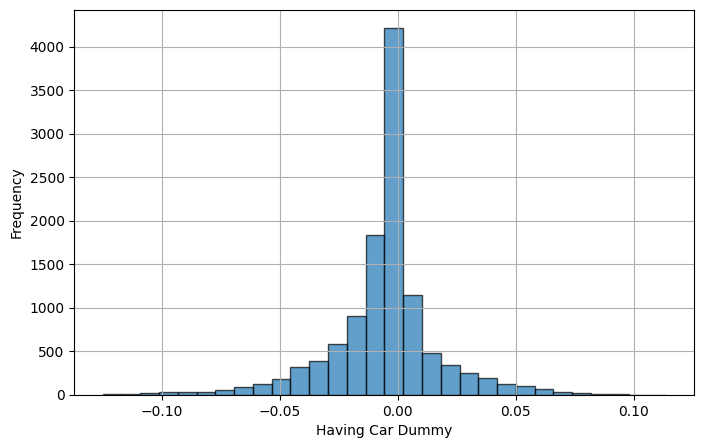

In [276]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Province Madhesh Dummy

In [277]:
importances.head(20).index

Index(['Education Year', 'Illiterate Dummy', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Literate Education Dummy',
       'Member with 12-Year Education or above Ratio',
       'Education under Secondary Certificate Dummy', 'Province Koshi Dummy',
       'Having Refrigator Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having TV Dummy',
       'Education with Secondary Certificate Dummy',
       'Farm Mechanization Dummy', 'Having Car Dummy',
       'Province Madhesh Dummy', 'Distance to Motorable Road',
       'Province Sudurpaschim Dummy'],
      dtype='object')

In [278]:
name = 'Province Madhesh Dummy'

In [279]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [280]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [281]:
prob_matrix.mean().mean()

0.0043091976925088895

In [282]:
prob_matrix.mean().std()

0.0010612895212453054

In [283]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

0.006389325154149687

In [284]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

0.0022290702308680912

In [285]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

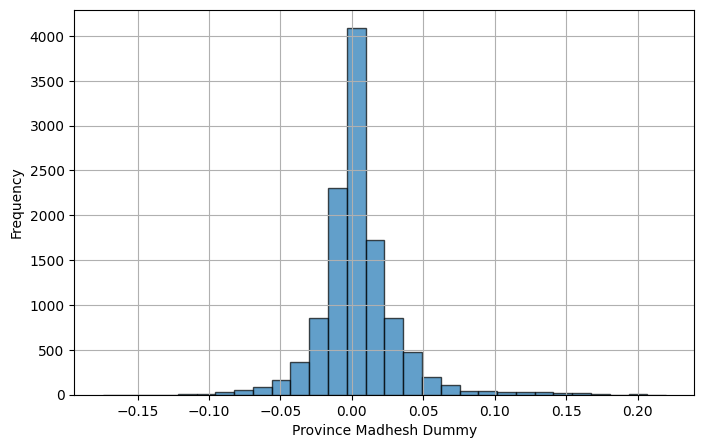

In [286]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Province Sudurpaschim Dummy

In [287]:
importances.head(20).index

Index(['Education Year', 'Illiterate Dummy', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Literate Education Dummy',
       'Member with 12-Year Education or above Ratio',
       'Education under Secondary Certificate Dummy', 'Province Koshi Dummy',
       'Having Refrigator Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having TV Dummy',
       'Education with Secondary Certificate Dummy',
       'Farm Mechanization Dummy', 'Having Car Dummy',
       'Province Madhesh Dummy', 'Distance to Motorable Road',
       'Province Sudurpaschim Dummy'],
      dtype='object')

In [288]:
name = 'Province Sudurpaschim Dummy'

In [289]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [290]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [291]:
prob_matrix.mean().mean()

-0.016561256644557064

In [292]:
prob_matrix.mean().std()

0.0012811232212990647

In [293]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

-0.014050255130810898

In [294]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

-0.01907225815830323

In [295]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

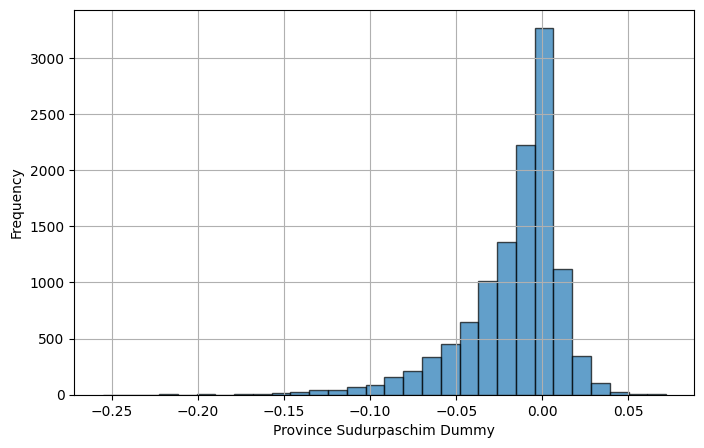

In [296]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Education Year

In [297]:
importances.head(20).index

Index(['Education Year', 'Illiterate Dummy', 'Having Computer Dummy',
       'Having Telephone Dummy', 'Survey Year', 'Having Mobile Dummy',
       'Literate Education Dummy',
       'Member with 12-Year Education or above Ratio',
       'Education under Secondary Certificate Dummy', 'Province Koshi Dummy',
       'Having Refrigator Dummy', 'Province Karnali Dummy',
       'EcoBelt Terai Dummy', 'Having TV Dummy',
       'Education with Secondary Certificate Dummy',
       'Farm Mechanization Dummy', 'Having Car Dummy',
       'Province Madhesh Dummy', 'Distance to Motorable Road',
       'Province Sudurpaschim Dummy'],
      dtype='object')

In [298]:
name = 'Education Year'

In [299]:
prob_matrix_list = []
for new_value in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 16, 18, 21]:
    prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        for epoch, random_seed in enumerate(range(42, 42*11, 42)):
            #print(f'fold: {fold}, random_seed:{random_seed}')
            clf = XGBClassifier(
                n_estimators=200, max_depth=8,
                learning_rate=0.05, subsample=1.0,
                colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
                eval_metric="logloss", tree_method="hist",          
                random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
            )
        
            clf.fit(X_train, y_train)
    
            # impact
            X_test_tide = X_test.copy()
            X_test_tide[name] = new_value
            y_proba_new = clf.predict_proba(X_test_tide)[:, 1]
            
            prob_matrix.iloc[test_idx, epoch] = y_proba_new

    prob_matrix_list.append(prob_matrix)

In [300]:
edu_years = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 16, 18, 21] 

In [304]:
mean_values = []
std_values = []
for prob_matrix in prob_matrix_list:
    mean_value = prob_matrix.mean().mean()
    std_value = prob_matrix.mean().std()
    mean_values.append(mean_value)
    std_values.append(std_value)

In [305]:
mean_values

[0.39523947614668675,
 0.39702892890279323,
 0.40260306945429936,
 0.40993327872746654,
 0.42526157339104964,
 0.44809732609117703,
 0.5000429698287342,
 0.5512923459522426,
 0.5579009397539701,
 0.6014957210468482,
 0.6103596559310439,
 0.6788529451878195,
 0.6899455325314092,
 0.7042459455668155,
 0.7184968920438106,
 0.7184968920438106]

In [306]:
std_values

[0.0026113594451647273,
 0.0017643623688004216,
 0.0013650464334237725,
 0.0010352599274574457,
 0.0016441602414816417,
 0.0027103012362749996,
 0.0033432922585650486,
 0.004688474234235859,
 0.004927819469938857,
 0.005957552152579184,
 0.006141012842495192,
 0.006494407011590519,
 0.007855987889780511,
 0.007899179581683517,
 0.00697324113285931,
 0.00697324113285931]

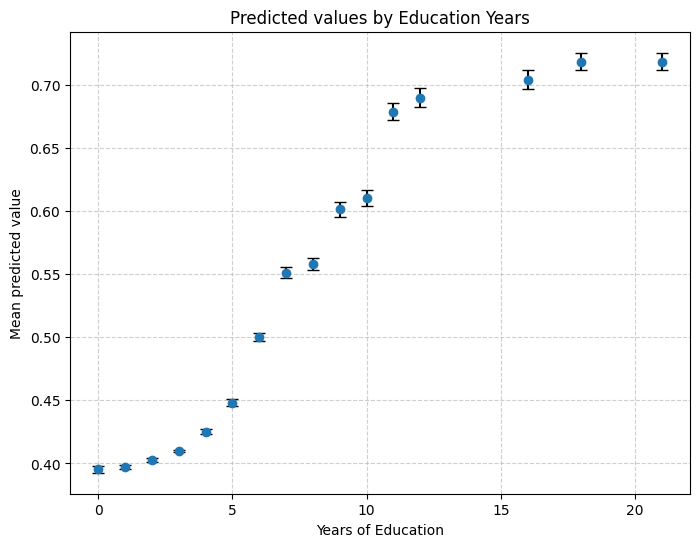

In [307]:
mean_values = np.array(mean_values)
std_values = np.array(std_values)

# Scatter plot with error bars
plt.figure(figsize=(8,6))
plt.errorbar(
    edu_years, mean_values, yerr=std_values,
    fmt='o', capsize=4, color="tab:blue", ecolor="black"
)
plt.xlabel("Years of Education")
plt.ylabel("Mean predicted value")
plt.title("Predicted values by Education Years")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Test

### Fit Model

In [23]:
y = df_inuse['HeardClimate_Dummy']
X = df_inuse.drop(columns = ['HeardClimate_Dummy'])

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

In [25]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [26]:
clf = XGBClassifier(
    n_estimators=1_000,
    max_depth=16,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",          # fast and memory-efficient
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

In [27]:
clf.fit(
    X_train, y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=16,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [28]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
try:
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
except ValueError:
    # If y is not binary or only one class present in y_test
    pass

Accuracy: 0.7675021607605877
ROC-AUC: 0.8434597760297975


In [29]:
print("\nClassification report:\n", classification_report(y_test, y_pred))


Classification report:
               precision    recall  f1-score   support

           0       0.79      0.82      0.80       669
           1       0.74      0.69      0.72       488

    accuracy                           0.77      1157
   macro avg       0.76      0.76      0.76      1157
weighted avg       0.77      0.77      0.77      1157



Confusion Matrix:
 [[549 120]
 [149 339]]


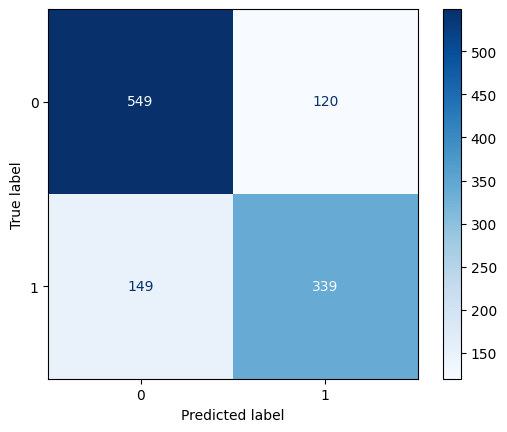

In [30]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# Optional: nice plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap="Blues")

### Importance

In [31]:
X_train.columns

Index(['Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_UnderSLC',
       'Edu_Certificate', 'Edu_Bachelor', 'Edu_Master', 'Edu_PhD',
       'Edu_Literal', 'Edu_Illiterate', 'Edu_year', 'Female_Ratio',
       'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio',
       'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 'Prov_Bagmati',
       'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
       'Prov_Gandaki', 'Prov_Karnali', 'ResidenceOwn_dummy',
       'ResidenceRent_dummy', 'ResidenceInstitu_dummy',
       'ResidenceOthers_dummy', 'ResidInfraPerman_dummy',
       'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy',
       'ResidInfraOthers_dummy', 'Remittance_dummy', 'Have_AgriLand',
       'HouseHead_AgriExpYear', 'Radio_dummy', 'TV_dummy', 'PC_dummy',
       'Net_dummy', 'Phone_dummy', 'Mobile_dummy', 'Motorbike_dummy',
       'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
       'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSu

In [33]:
# Get importance values
importances = pd.Series(clf.feature_importances_, index=X_train.columns)

# Sort descending
importances = importances.sort_values(ascending=False)

print(importances.head(20))   # Top 20 important features

PC_dummy                  0.061520
Edu_year                  0.058310
Year                      0.044248
Edu_Illiterate            0.036198
Mobile_dummy              0.023528
Phone_dummy               0.022474
EcoBelt_Terai             0.021797
Prov_Koshi                0.021126
Prov_Karnali              0.019946
Car_dummy                 0.017083
TV_dummy                  0.016104
FramMechan                0.015550
OtherVehi_dummy           0.015068
Refrige_dummy             0.014868
Dist_Road                 0.014607
ResidInfraPerman_dummy    0.014173
CropIncome                0.014036
EcoBelt_Mountain          0.014027
Prov_Madhesh              0.013987
Have_AgriLand             0.013521
dtype: float32


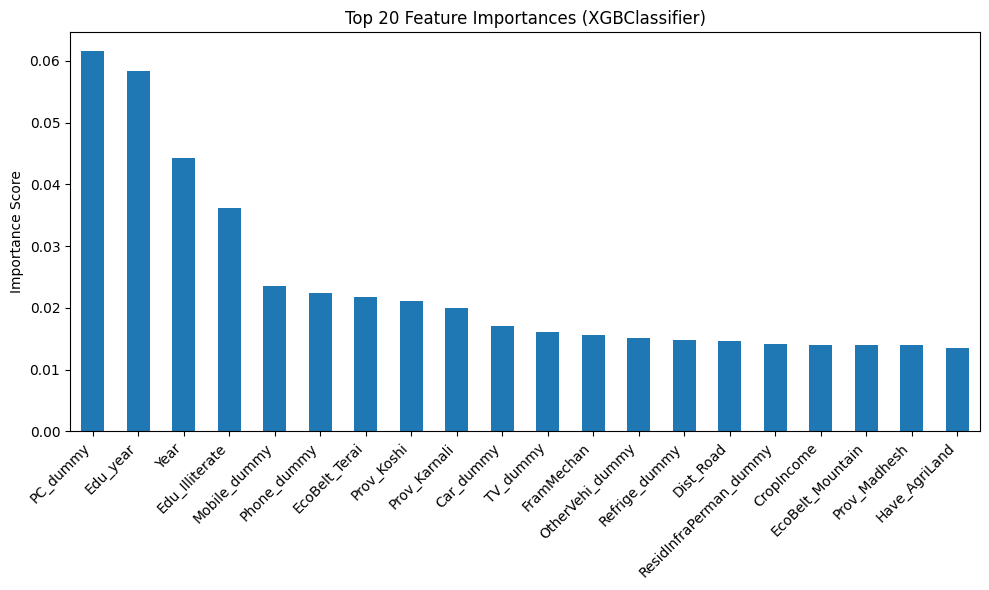

In [34]:
plt.figure(figsize=(10,6))
importances.head(20).plot(kind="bar")
plt.title("Top 20 Feature Importances (XGBClassifier)")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [57]:
importances.head(20).index

Index(['Edu_Illiterate', 'PC_dummy', 'Year', 'Edu_Literal', 'Mobile_dummy',
       'Edu_Certificate', 'Edu12_Ratio', 'Edu_Bachelor', 'Phone_dummy',
       'TV_dummy', 'Edu_UnderSLC', 'Edu_Master', 'Respon_Female', 'Dist_Road',
       'Refrige_dummy', 'CropIncome', 'AgriSupport', 'OtherVehi_dummy',
       'Car_dummy', 'Net_dummy'],
      dtype='object')

### Checking Impacts

Edu_Illiterate, -0.1794


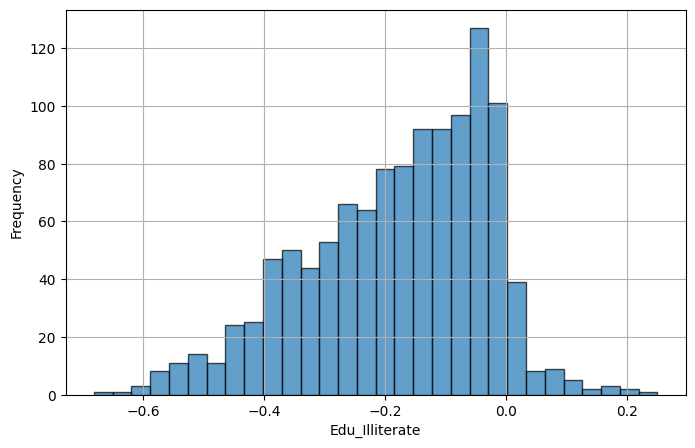

PC_dummy, 0.0655


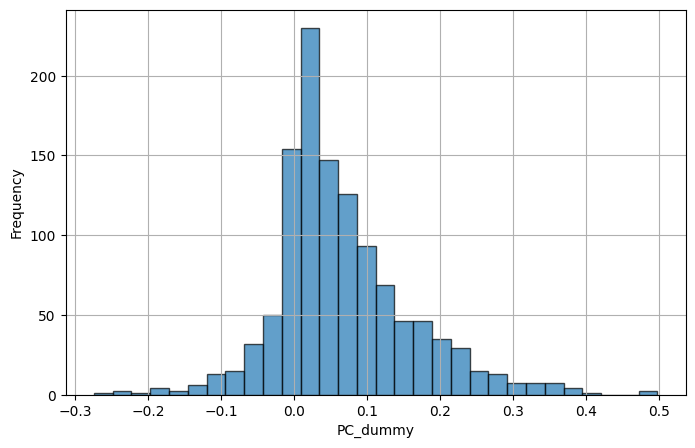

Edu_Literal, -0.0500


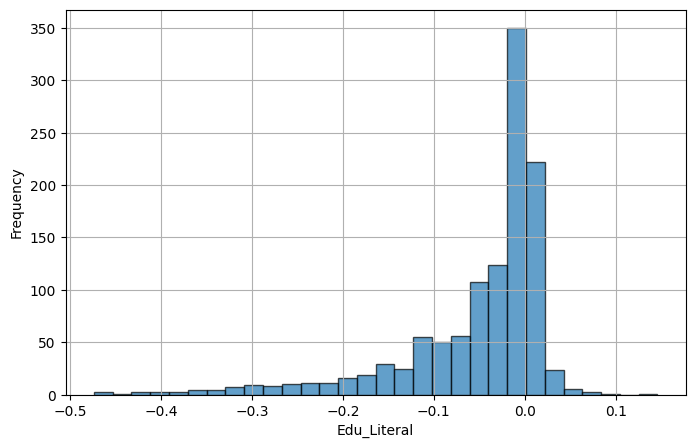

Mobile_dummy, -0.0509


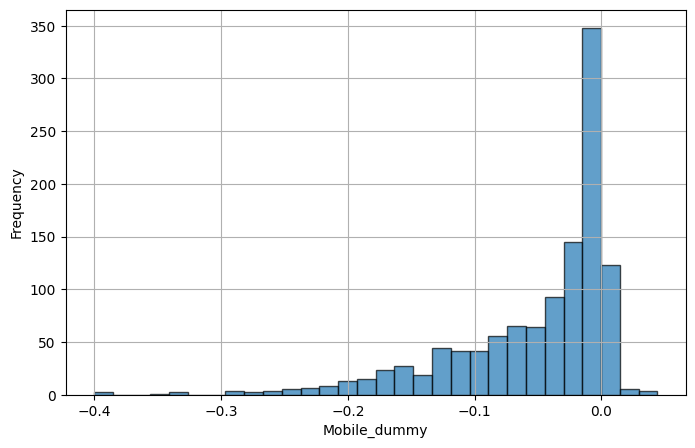

Edu_Certificate, 0.0750


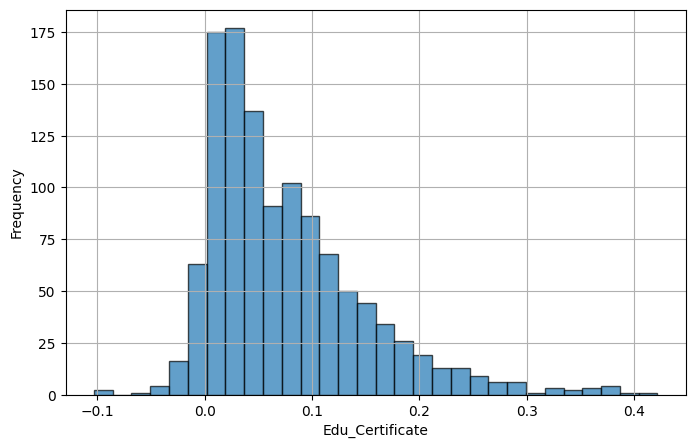

Edu_Bachelor, 0.0596


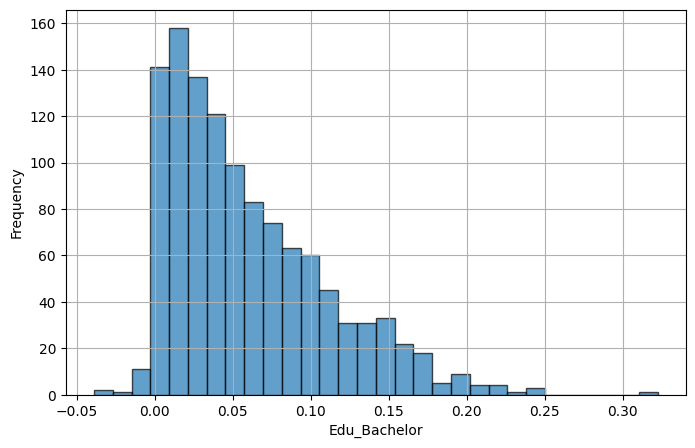

TV_dummy, 0.0334


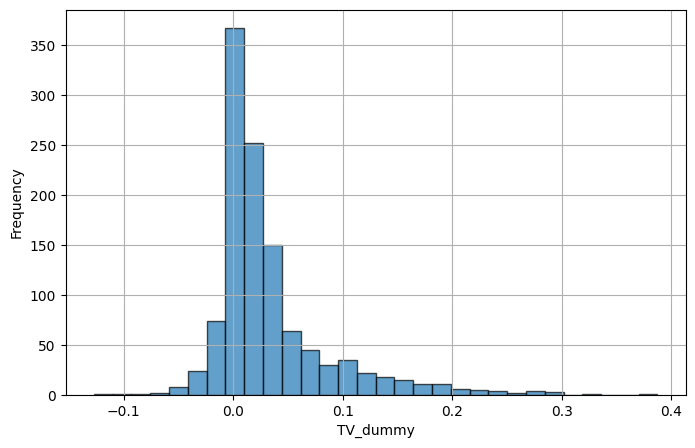

Phone_dummy, 0.0208


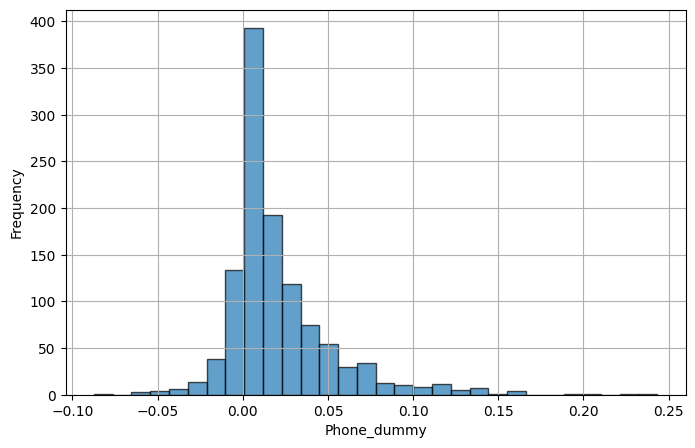

Edu_Master, 0.0596


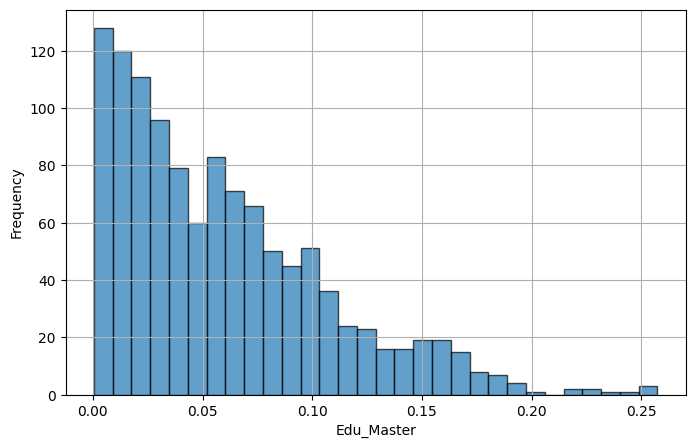

Respon_Female, -0.0873


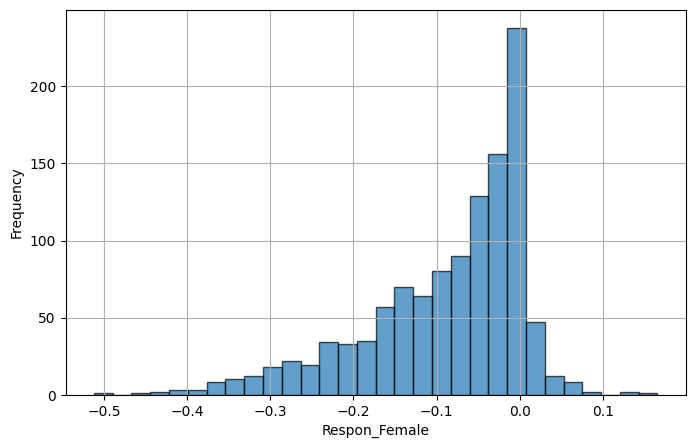

Edu_UnderSLC, 0.0302


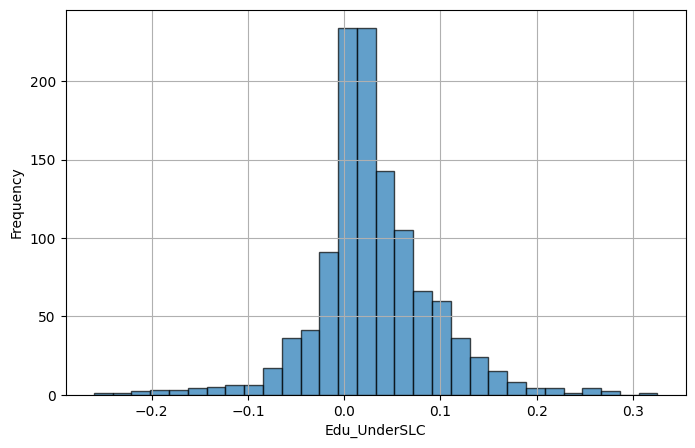

AgriSupport, 0.0344


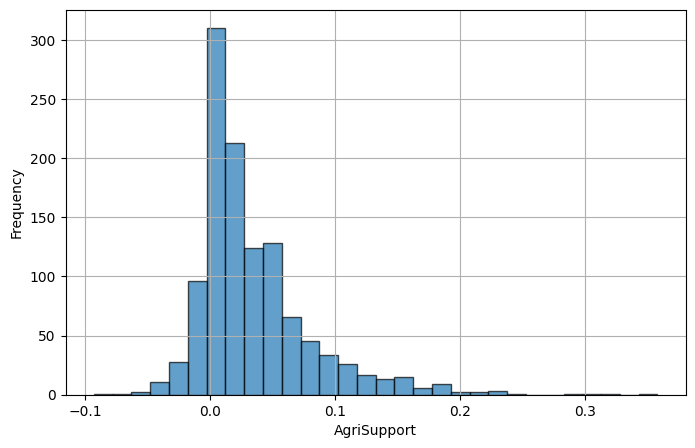

Radio_dummy, 0.0376


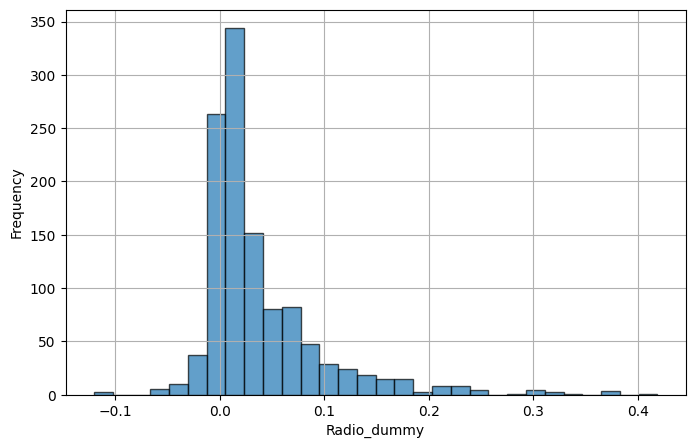

Refrige_dummy, 0.0123


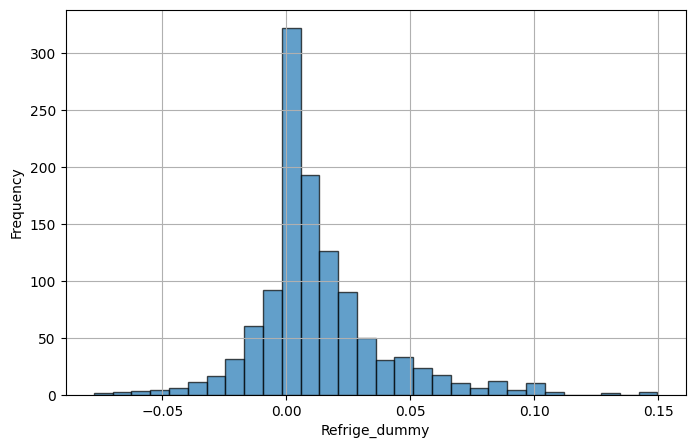

Net_dummy, 0.0152


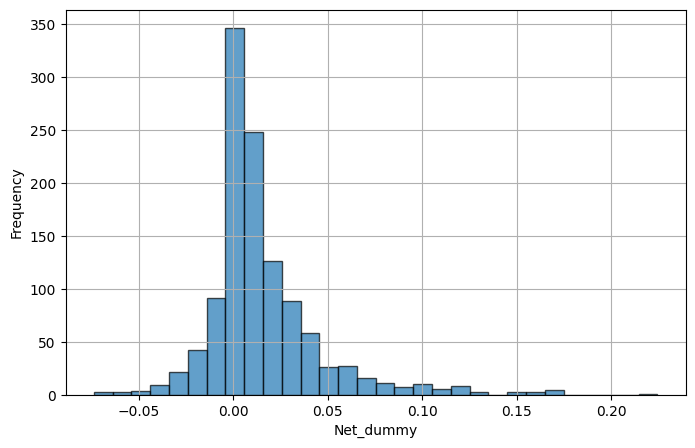

In [58]:
for name in ['Edu_Illiterate', 'PC_dummy', 'Edu_Literal', 'Mobile_dummy',
       'Edu_Certificate', 'Edu_Bachelor', 'TV_dummy',
       'Phone_dummy', 'Edu_Master', 'Respon_Female', 'Edu_UnderSLC',
       'AgriSupport', 'Radio_dummy', 'Refrige_dummy', 'Net_dummy']:
    X_test_tide = X_test.copy()
    X_test_tide[name] = 1
    y_proba_true = clf.predict_proba(X_test_tide)[:, 1]

    X_test_tide = X_test.copy()
    X_test_tide[name] = 0
    y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    

    y_proba_diff = y_proba_true - y_proba_false
    print(f"{name}, {np.mean(y_proba_diff):.04f}")

    plt.figure(figsize=(8,5))
    plt.hist(y_proba_diff, bins=30, edgecolor="black", alpha=0.7)
    plt.xlabel(name)
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

In [31]:
y_proba_diff

array([-0.1053277 , -0.21896806, -0.23846263, ...,  0.21430153,
       -0.08145863, -0.41204885], dtype=float32)